In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("..")
import gp
import pickle
import matplotlib.pyplot as plt
import numpy as np
from pandas import DataFrame
import openpyxl
import math
# Making table for testing masses. Currently gives lots of inf values for unknown reason.
mass_hypothesis = .100
mass_hypotheses = np.linspace(.033,.179,147).tolist()
rebin = 2
# Coefficients for the polynomial from the table for unsmeared (P0 to P4)
coefficients = [0.00032, 0.019, -0.11, 1.39, -4.33]

#Smeared Coefficients
#coefficients = [0.00038,0.041,-0.27,3.49,-11.11]


def sigma(mass, coeffs):
    #sigma is twice the mass resolution
    return sum(c * mass**i for i, c in enumerate(coeffs))

def sigmas(masses, coeffs):
    sigma_list = []
    for mass in masses:
        sigma_list.append(sum(c * mass**i for i, c in enumerate(coeffs)))
    return sigma_list

'''
def make_table(masses, coeffs):
    sigma_list = sigmas(masses, coeffs)
    ul_list = []
    for i in range(len(masses)):
        
        m = gp.GaussianProcessModel(
            h = 'EventSelection_Data_10Percent.root', # use real IMD from ROOT file in this directory
            kernel = gp.kernels.Product(gp.kernels.RBF(), gp.kernels.DotProduct()),
            #kernel = gp.kernels.RBF(),
            blind_range = (masses[i]-(sigma_list[i]), masses[i]+(sigma_list[i])),
            #modify_histogram = [gp._hist.manipulation.rebin_and_limit(10, 0.033, 0.179), gp._hist.manipulation.inject_signal(5000,sigma(mass_hypothesis, coefficients),mass_hypothesis)]
            modify_histogram = gp._hist.manipulation.rebin_and_limit(10, 0.035, 0.179)
        )
        m.model
        m.model.kernel_
        ul_list.append(m.upper_limit_in_blind_region())
    return ul_list
    '''
def make_table(masses, coeffs):
    sigma_list = sigmas(masses, coeffs)
    ul_list = []
    for i in range(len(masses)):
        # Print blind range for debugging
        blind_range = (masses[i] - sigma_list[i], masses[i] + sigma_list[i])
        print(f"Mass: {masses[i]}, Sigma: {sigma_list[i]}, Blind Range: {blind_range}")
        
        try:
            # Create the model with the current mass and blind range
            m = gp.GaussianProcessModel(
                h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'),
                kernel = gp.kernels.WhiteKernel() + gp.kernels.RBF() * gp.kernels.DotProduct(),
                blind_range = blind_range,
                modify_histogram = gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179)
            )
            # Calculate upper limit
            upper_limit = m.upper_limit_in_blind_region()
        except Exception as e:
            print(f"Error for mass {masses[i]}: {e}")
            upper_limit = float('inf')  # or a fallback value

        ul_list.append(upper_limit)

    return ul_list, sigma_list

ul1, sl = make_table(mass_hypotheses, coefficients)
# Put table in Excel file

df = DataFrame({'Mass': mass_hypotheses, 'Blind Range Size': [i*2 for i in sl], 'Upper Limit': ul1})
df.to_csv('ul_test.csv', index=False)


Mass: 0.033, Sigma: 0.0008720273920700001, Blind Range: (0.03212797260793, 0.03387202739207)
Mass: 0.034, Sigma: 0.00088768622512, Blind Range: (0.033112313774880005, 0.03488768622512)
Mass: 0.035, Sigma: 0.00090334854375, Blind Range: (0.03409665145625, 0.035903348543750005)
Mass: 0.036000000000000004, Sigma: 0.00091901910272, Blind Range: (0.035080980897280005, 0.036919019102720003)
Mass: 0.037000000000000005, Sigma: 0.00093470255287, Blind Range: (0.03606529744713, 0.03793470255287001)
Mass: 0.038, Sigma: 0.0009504034411200001, Blind Range: (0.03704959655888, 0.038950403441119996)
Mass: 0.039, Sigma: 0.00096612621047, Blind Range: (0.03803387378953, 0.03996612621047)
Mass: 0.04, Sigma: 0.0009818752, Blind Range: (0.0390181248, 0.040981875200000004)
Mass: 0.041, Sigma: 0.00099765464487, Blind Range: (0.04000234535513, 0.04199765464487)
Mass: 0.042, Sigma: 0.00101346867632, Blind Range: (0.040986531323680006, 0.04301346867632)
Mass: 0.043000000000000003, Sigma: 0.00102932132167, Blind

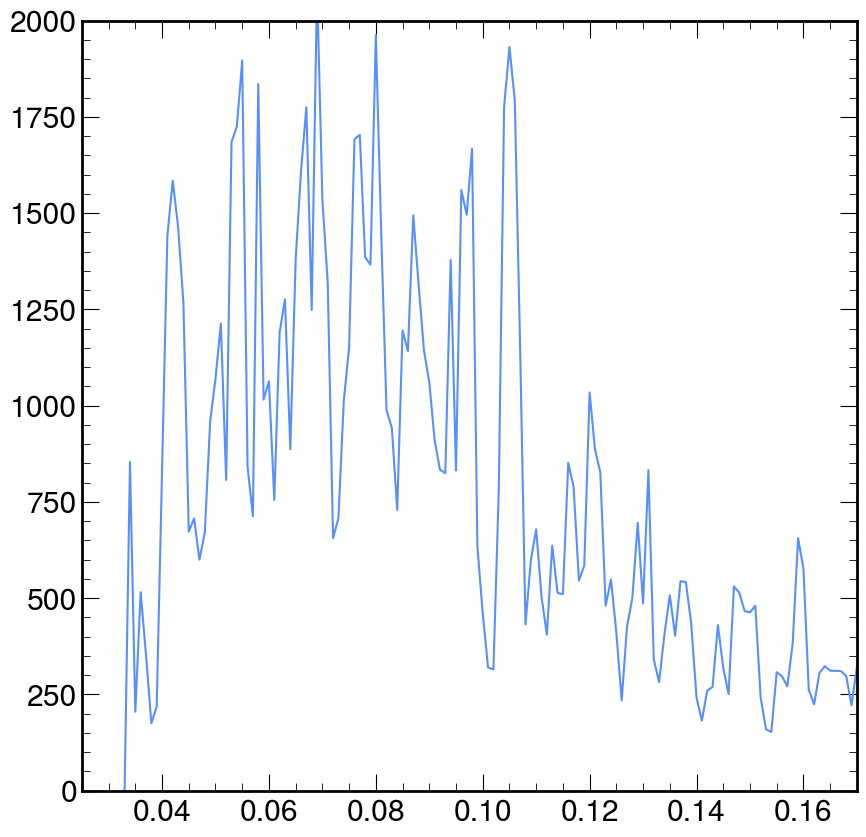

In [2]:
plot_ul = []
plot_masses = []
error_list = []
for i in range(len(ul1)):
    if not math.isinf(ul1[i]):
        plot_ul.append(ul1[i])
        plot_masses.append(mass_hypotheses[i])
    else:
        error_list.append(mass_hypotheses[i])

plt.plot(plot_masses, plot_ul, label='Upper Limit vs Mass')
plt.vlines(error_list, 0, 8000, 'r')
ax1 = plt.gca()
ax1.set_xlim([.025, .170])
ax1.set_ylim([0, 2000])
df2 = DataFrame({'Mass': plot_masses, 'Upper Limit': plot_ul})
df2.to_excel('ul_test_fixed.xlsx', sheet_name='sheet1', index=False)
df2.to_csv('ul_test_fixed.csv', index=False)